In [50]:
import importlib
import src.config as config_module
importlib.reload(config_module)

import src.model as model_module
importlib.reload(model_module)
from src.model import build_model, train_model

from src.config import TFT_PARAMS, QUANTILES, MODELS_DIR
print("✅ Importado correctamente")
print(TFT_PARAMS)

✅ Importado correctamente
{'input_chunk_length': 50, 'output_chunk_length': 10, 'hidden_size': 64, 'lstm_layers': 2, 'num_attention_heads': 4, 'dropout': 0.1, 'batch_size': 32, 'n_epochs': 100, 'random_state': 42}


In [51]:
import sys
from pathlib import Path
import pandas as pd

sys.path.append(str(Path.cwd().parent))
from src.config import DATA_PROC

import importlib
import src.dataset as dataset_module
importlib.reload(dataset_module)

from src.dataset import load_labeled_data, get_train_val_series
from src.model import build_model, train_model


In [52]:
df = load_labeled_data(DATA_PROC / "all_features_labeled.csv")

train_targets, train_past_covs, val_targets, val_past_covs, scaler = get_train_val_series(df)

print(f"\nTrain series : {len(train_targets)}")
print(f"Val series   : {len(val_targets)}")

for i, (t, p) in enumerate(zip(train_targets, train_past_covs)):
    print(f"\nTrain [{i}] → target shape: {t.values().shape} | past_cov shape: {p.values().shape}")

for i, (t, p) in enumerate(zip(val_targets, val_past_covs)):
    print(f"Val   [{i}] → target shape: {t.values().shape} | past_cov shape: {p.values().shape}")

  exp1 - bearing_3: 2007 snapshots (fp=2006)
  exp1 - bearing_4: 1625 snapshots (fp=1624)
  exp2 - bearing_1: 689 snapshots (fp=688)
  exp3 - bearing_3: 5938 snapshots (fp=5937)

Train series : 3
Val series   : 1

Train [0] → target shape: (2007, 1) | past_cov shape: (2007, 15)

Train [1] → target shape: (1625, 1) | past_cov shape: (1625, 15)

Train [2] → target shape: (689, 1) | past_cov shape: (689, 15)
Val   [0] → target shape: (5938, 1) | past_cov shape: (5938, 15)


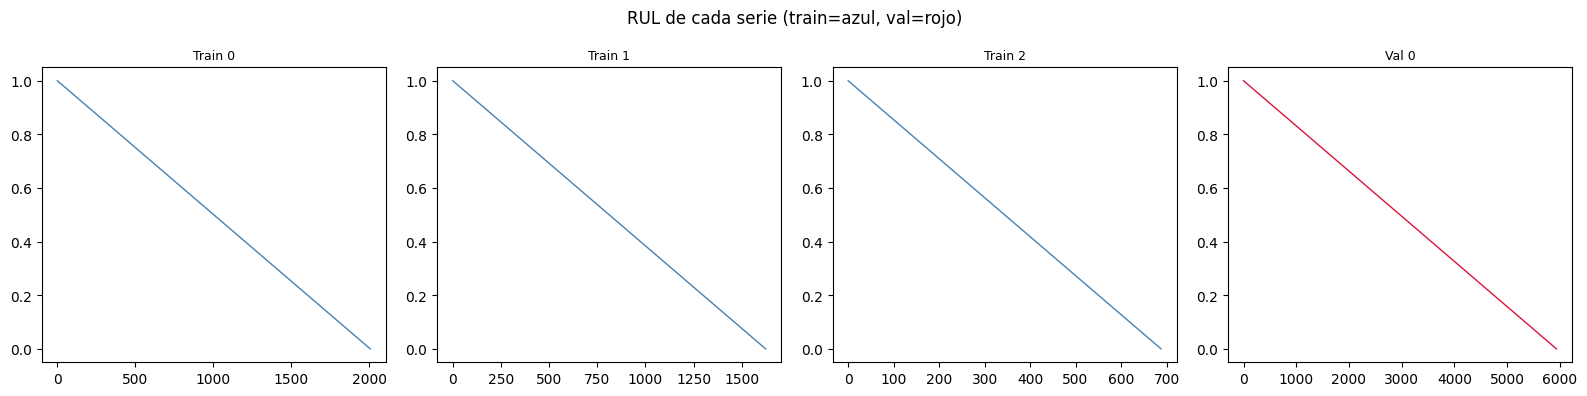

In [53]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(train_targets) + len(val_targets), figsize=(16, 4))
fig.suptitle("RUL de cada serie (train=azul, val=rojo)", fontsize=12)

for i, ts in enumerate(train_targets):
    axes[i].plot(ts.values(), color="steelblue", linewidth=1)
    axes[i].set_title(f"Train {i}", fontsize=9)
    axes[i].set_ylim(-0.05, 1.05)

for j, ts in enumerate(val_targets):
    axes[len(train_targets) + j].plot(ts.values(), color="crimson", linewidth=1)
    axes[len(train_targets) + j].set_title(f"Val {j}", fontsize=9)
    axes[len(train_targets) + j].set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.show()

In [54]:
df = load_labeled_data(DATA_PROC / "all_features_labeled.csv")

train_targets, train_past_covs, val_targets, val_past_covs, scaler = get_train_val_series(df)

print(f"Train series : {len(train_targets)}")
print(f"Val series   : {len(val_targets)}")

  exp1 - bearing_3: 2007 snapshots (fp=2006)
  exp1 - bearing_4: 1625 snapshots (fp=1624)
  exp2 - bearing_1: 689 snapshots (fp=688)
  exp3 - bearing_3: 5938 snapshots (fp=5937)
Train series : 3
Val series   : 1


In [55]:
model = build_model()

model = train_model(
    model           = model,
    train_targets   = train_targets,
    train_past_covs = train_past_covs,
    val_targets     = val_targets,
    val_past_covs   = val_past_covs,
)

print("Entrenamiento completado")

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

   | Name                              | Type                             | Params | Mode  | FLOPs
--------------------------------------------------------------------------------------------------------
0  | train_metrics                     | MetricCollection                 | 0      | train | 0    
1  | val_metrics                       | MetricCollection                 | 0      | train | 0    
2  | input_embeddings                  | _MultiEmbedding                  | 0      | train | 0    
3  | static_covariates_vsn             | _VariableSelectionNetwork        | 3.3 K  | train | 0    
4  | encoder_vsn                       | _VariableSelectionNetwork        | 32.2 K | train | 0

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/adrian-pc/yes/envs/rul_bearing/lib/python3.10/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/adrian-pc/yes/envs/rul_bearing/lib/python3.10/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]


Detected KeyboardInterrupt, attempting graceful shutdown ...


SystemExit: 1

/home/adrian-pc/yes/envs/rul_bearing/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3587: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)
